In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Carregando os dados
df = pd.read_csv('winequality-red.csv', delimiter=';')
#colunas = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sufur dioxide', 'density', 'ph', 'sulphates', 'alcohol', 'quality']

In [ ]:
# Exibir as cinco primeiras linhas do dataframe
#df = pd.read_csv('winequality-red.csv', header=None, names=colunas)
print(df.head(5))

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [ ]:
df

,fixed acidity,volatile acidity,citric acid,chlorides,total sulfur dioxide,density,sulphates,alcohol,quality
0,7.4,0.700,0.00,0.076,34.0,0.99780,0.56,9.4,5
1,7.8,0.880,0.00,0.098,67.0,0.99680,0.68,9.8,5
2,7.8,0.760,0.04,0.092,54.0,0.99700,0.65,9.8,5
3,11.2,0.280,0.56,0.075,60.0,0.99800,0.58,9.8,6
4,7.4,0.700,0.00,0.076,34.0,0.99780,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,0.090,44.0,0.99490,0.58,10.5,5
1595,5.9,0.550,0.10,0.062,51.0,0.99512,0.76,11.2,6
1596,6.3,0.510,0.13,0.076,40.0,0.99574,0.75,11.0,6
1597,5.9,0.645,0.12,0.075,44.0,0.99547,0.71,10.2,5


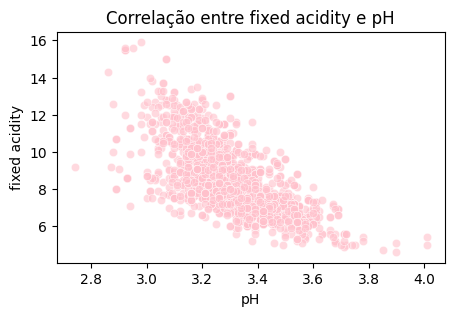

In [ ]:
plt.figure(figsize=(5, 3))
sns.scatterplot(x='pH', y='fixed acidity', data=df, color='pink', alpha=0.6)
plt.title('Correlação entre fixed acidity e pH')
plt.xlabel('pH')
plt.ylabel('fixed acidity')
plt.show()

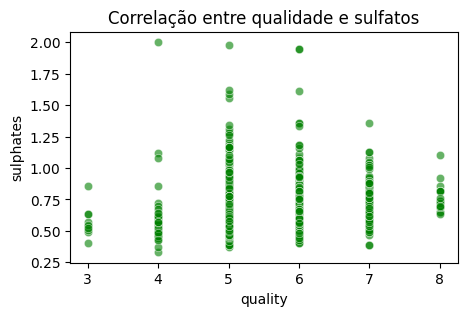

In [ ]:
plt.figure(figsize=(5, 3))
sns.scatterplot(x='quality', y='sulphates', data=df, color='green', alpha=0.6)
plt.title('Correlação entre qualidade e sulfatos')
plt.xlabel('quality')
plt.ylabel('sulphates')
plt.show()

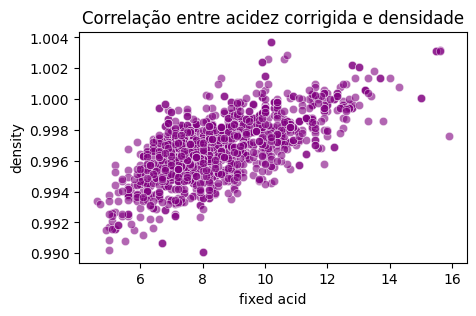

In [ ]:
plt.figure(figsize=(5, 3))
sns.scatterplot(x='fixed acidity', y='density', data=df, color='purple', alpha=0.6)
plt.title('Correlação entre acidez corrigida e densidade')
plt.xlabel('fixed acid')
plt.ylabel('density')
plt.show()

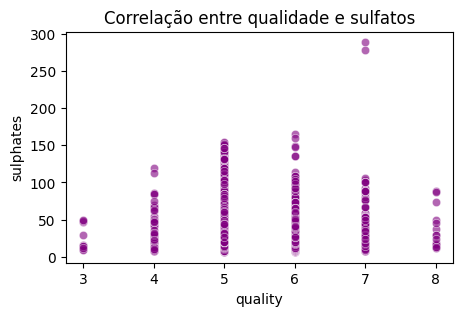

In [ ]:
plt.figure(figsize=(5, 3))
sns.scatterplot(x='quality', y='total sulfur dioxide', data=df, color='purple', alpha=0.6)
plt.title('Correlação entre qualidade e sulfatos')
plt.xlabel('quality')
plt.ylabel('sulphates')
plt.show()

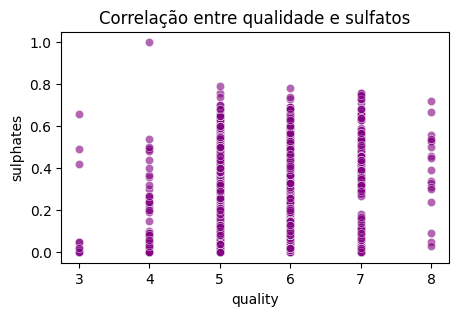

In [ ]:
plt.figure(figsize=(5, 3))
sns.scatterplot(x='quality', y='citric acid', data=df, color='purple', alpha=0.6)
plt.title('Correlação entre qualidade e sulfatos')
plt.xlabel('quality')
plt.ylabel('sulphates')
plt.show()

In [ ]:
#Transformando os dados em Dataframe
df = pd.read_csv('winequality-red.csv', sep=';')

In [ ]:
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [ ]:
# Correlacionando as variáveis (colunas)
correlation_columns = df.columns

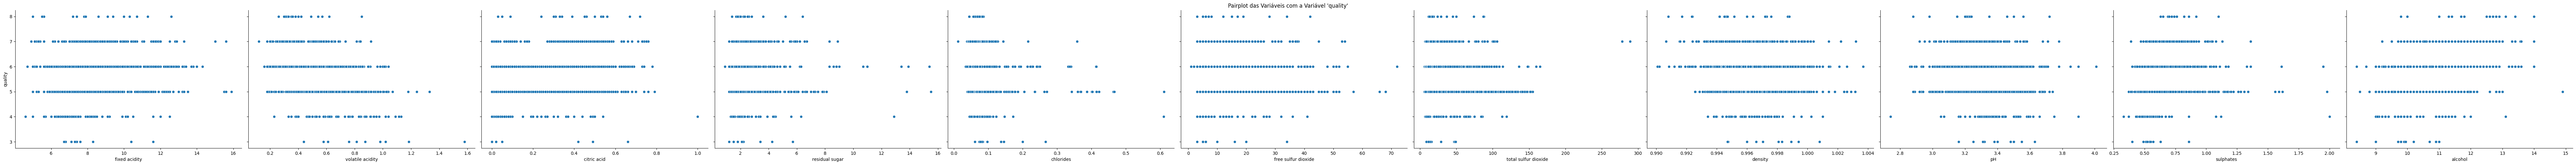

In [ ]:
#Criando Pairplot
sns.pairplot(df, y_vars='quality', x_vars=correlation_columns[:-1], aspect=1.5, height=5)
plt.suptitle("Pairplot das Variáveis com a Variável 'quality'", y=1.02)  # Título do gráfico
plt.show()

In [ ]:
#Calculando a matriz de correlação
correlation_matrix = df.corr()

In [ ]:
print(correlation_matrix)

                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.256131     0.671703   
volatile acidity          -0.256131          1.000000    -0.552496   
citric acid                0.671703         -0.552496     1.000000   
residual sugar             0.114777          0.001918     0.143577   
chlorides                  0.093705          0.061298     0.203823   
free sulfur dioxide       -0.153794         -0.010504    -0.060978   
total sulfur dioxide      -0.113181          0.076470     0.035533   
density                    0.668047          0.022026     0.364947   
pH                        -0.682978          0.234937    -0.541904   
sulphates                  0.183006         -0.260987     0.312770   
alcohol                   -0.061668         -0.202288     0.109903   
quality                    0.124052         -0.390558     0.226373   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity    

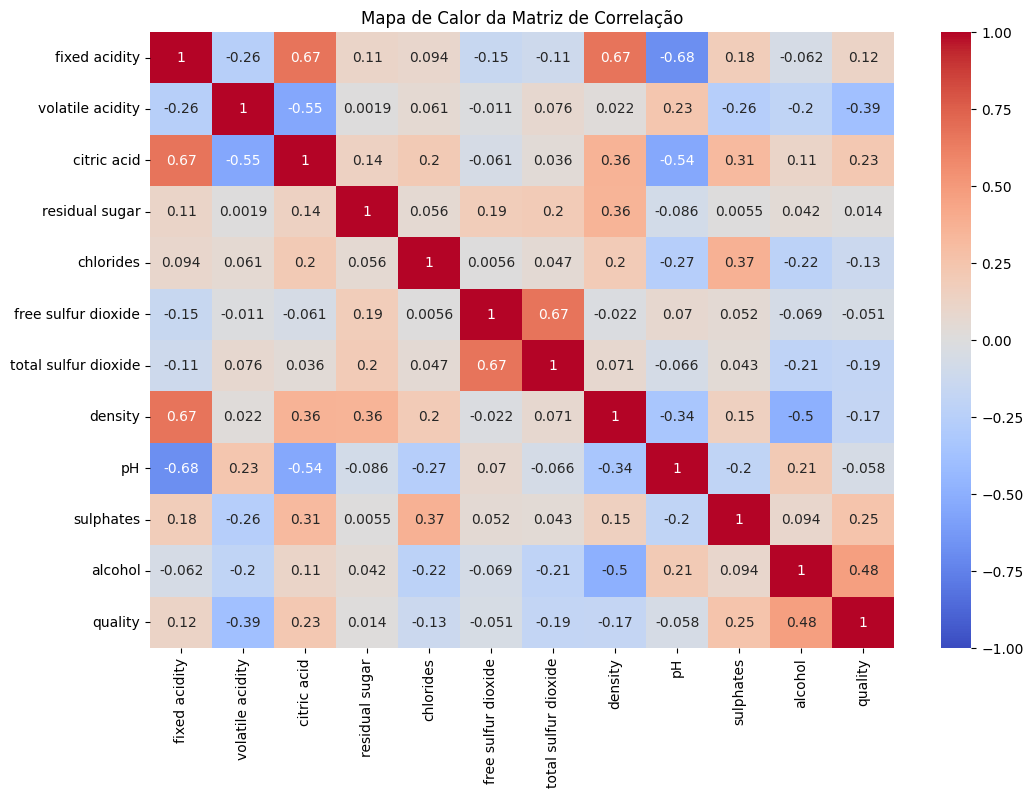

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Mapa de Calor da Matriz de Correlação")
plt.show()



# 1.    Pré-Processamento dos Dados





In [ ]:
#Excluindo colunas com fraca correlação
colunas_para_excluir = ['residual sugar', 'free sulfur dioxide', 'pH' ]
df = df.drop(columns=colunas_para_excluir)

In [ ]:
#Definindo os eixos
X = df.drop('quality', axis=1)
y = df['quality']

In [ ]:
# Normalização dos dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2.    Criação do Modelo





##Definição dos Conjuntos de Treino e Teste

In [ ]:
# Definindo Conjuntos de Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

###Visualização dos Conjuntos

In [ ]:
#Verificando a base de treinamento
X_train

,fixed acidity,volatile acidity,citric acid,chlorides,total sulfur dioxide,density,sulphates,alcohol
925,8.6,0.220,0.36,0.064,77.0,0.99604,0.87,11.0
363,12.5,0.460,0.63,0.071,15.0,0.99880,0.87,10.2
906,7.2,0.540,0.27,0.084,78.0,0.99640,0.71,11.0
426,6.4,0.670,0.08,0.045,48.0,0.99490,0.49,11.4
1251,7.5,0.580,0.14,0.077,60.0,0.99630,0.59,9.8
...,...,...,...,...,...,...,...,...
1130,9.1,0.600,0.00,0.058,10.0,0.99770,0.63,10.4
1294,8.2,0.635,0.10,0.073,60.0,0.99638,0.75,10.9
860,7.2,0.620,0.06,0.077,85.0,0.99746,0.54,9.5
1459,7.9,0.200,0.35,0.054,15.0,0.99458,0.80,11.9


In [ ]:
#Tamanho da base de treinamento
X_train.shape

(1119, 8)

In [ ]:
#Tamanho da Base de teste
X_test.shape

(480, 8)

# 3. Testando o Modelo





In [ ]:
#Instanciando KNN para k=2
k=2
model_1 = KNeighborsRegressor (n_neighbors=k)
#treinando o Modelo
model_1.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=2)

In [ ]:
# Salvando nas variáveis para guardar os resultados do modelo
y_pred = model_1.predict(X_test)

# 4. Avaliação do Modelo - Métricas



In [ ]:
# Métricas de desempenho do modelo
mse1 = mean_squared_error(y_test, y_pred)
mae1 = mean_absolute_error(y_test, y_pred)

print(f'Mean Squared Error (MSE1): {round(mse1, 2)}')
print(f'Mean Absolute Error (MAE1): {round(mae1, 2)}')

Mean Squared Error (MSE1): 0.59
Mean Absolute Error (MAE1): 0.56


In [ ]:
# Coeficiente de determinação (R²)
r2 = r2_score(y_test, y_pred)
print("Coeficiente de Determinação (R²):", r2)

Coeficiente de Determinação (R²): 0.07337810362885844


## 4.1 Gráficos de Visualização do Modelo 1

<ipython-input-164-dfa580c7e56f>:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2, color= 'darkblue')


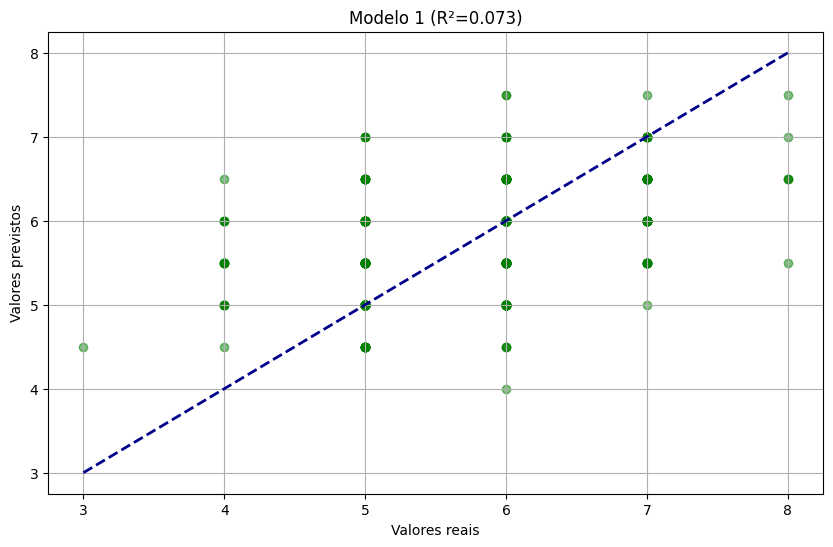

In [ ]:
# Visualizando os resultados da função previsão
plt.figure(figsize=(10, 6))
# Gráfico de previsão versus valor real
plt.scatter(y_test, y_pred, color = 'green', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2, color= 'darkblue')
plt.title(f'Modelo 1 (R²={r2:.3f})')
plt.xlabel('Valores reais')
plt.ylabel('Valores previstos')
plt.grid(True)
plt.show()

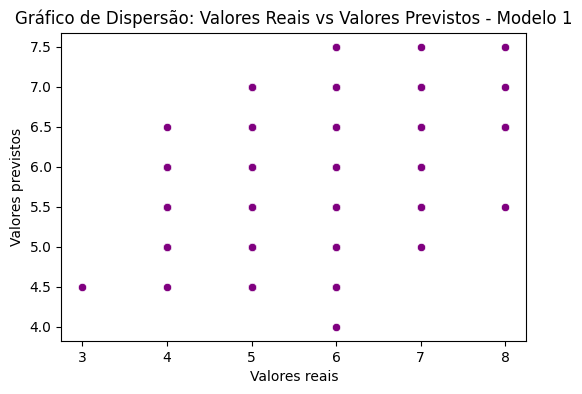

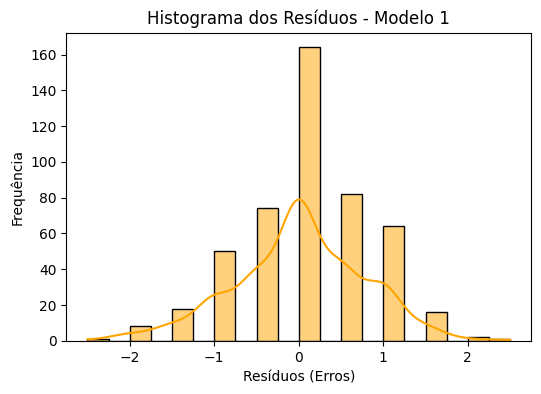

In [ ]:
# Calcula os resíduos (diferença entre valores previstos e valores reais)
residuals = y_test - y_pred

# Plotar um gráfico de dispersão dos valores previstos em relação aos valores reais
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=y_pred, color='purple')
plt.xlabel('Valores reais')
plt.ylabel('Valores previstos')
plt.title('Gráfico de Dispersão: Valores Reais vs Valores Previstos - Modelo 1')
plt.show()

# Plotar um histograma dos resíduos
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, color='orange')
plt.xlabel('Resíduos (Erros)')
plt.ylabel('Frequência')
plt.title('Histograma dos Resíduos - Modelo 1')
plt.show()

# 5. Melhorando Parâmetros e Construção do Modelo 2


In [ ]:
# Definindo o modelo 2 do Knn Regressor
model_2 = KNeighborsRegressor()

In [ ]:
# Definindo os parâmetros a serem testados
list(range(2,15))

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

In [ ]:

k_values = list(range(2,15))

#Lista para armazenar os scores médios de validação cruzada para cada valor de k
cv_scores = []

#Loop sobre os valores de k
for k in k_values:
    model_2 = KNeighborsRegressor(n_neighbors=k)    #Criando Modelo de Regressão
    scores = cross_val_score(model_2, X_train, y_train, cv=5, scoring='neg_mean_squared_error')   #Fazendo validação cruzada
    cv_scores.append(scores.mean())
    print(f'K: {k} | Score:{scores}')



K: 2 | Score:[-0.64174107 -0.65625    -0.6328125  -0.58258929 -0.65134529]
K: 3 | Score:[-0.58531746 -0.61011905 -0.54910714 -0.55803571 -0.57100149]
K: 4 | Score:[-0.60184152 -0.60491071 -0.5186942  -0.5078125  -0.53307175]
K: 5 | Score:[-0.60625    -0.57089286 -0.47214286 -0.53303571 -0.49596413]
K: 6 | Score:[-0.58940972 -0.57837302 -0.50434028 -0.53658234 -0.47745391]
K: 7 | Score:[-0.59183673 -0.59730321 -0.50756195 -0.53516764 -0.45218267]
K: 8 | Score:[-0.61363002 -0.58217076 -0.50404576 -0.53369141 -0.46153307]
K: 9 | Score:[-0.63244048 -0.57501102 -0.52083333 -0.53339947 -0.45540608]
K: 10 | Score:[-0.62258929 -0.56334821 -0.51995536 -0.53986607 -0.46318386]
K: 11 | Score:[-0.62127361 -0.55681818 -0.51911157 -0.54895956 -0.45458251]
K: 12 | Score:[-0.62822421 -0.55292039 -0.50489831 -0.55047123 -0.46119831]
K: 13 | Score:[-0.62185651 -0.54377113 -0.50203402 -0.55180156 -0.4556213 ]
K: 14 | Score:[-0.61784803 -0.54801385 -0.50605867 -0.55471028 -0.45556877]


## 5.1 Encontrando o Melhor valor de k

In [ ]:
# Encontrando melhor valor de k

best_k = k_values[cv_scores.index(max(cv_scores))]
best_k


13

##  5.2 Testando o Modelo 2 com o melhor valor de k


In [ ]:
#Treinando o Modelo com o Best_k
model_2 = KNeighborsRegressor(n_neighbors=best_k)
model_2.fit(X_train, y_train)


KNeighborsRegressor(n_neighbors=13)

In [ ]:
# Previsões
y_pred_2 = model_2.predict(X_test)

#5.3 Avaliação do Modelo 2 - Métricas

In [ ]:
# Métricas de desempenho do modelo
mse2 = mean_squared_error(y_test, y_pred_2)
mae2 = mean_absolute_error(y_test, y_pred_2)

print(f'Mean Squared Error (MSE2): {round(mse2, 2)}')
print(f'Mean Absolute Error (MAE2): {round(mae2, 2)}')

Mean Squared Error (MSE2): 0.5
Mean Absolute Error (MAE2): 0.56


In [ ]:
# Coeficiente de determinação (R²)
r2m2 = r2_score(y_test, y_pred_2)
print("Coeficiente de Determinação (R²):", r2m2)

Coeficiente de Determinação (R²): 0.21158005166289418


<ipython-input-151-c9379fc5be3c>:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2, color= 'darkblue')


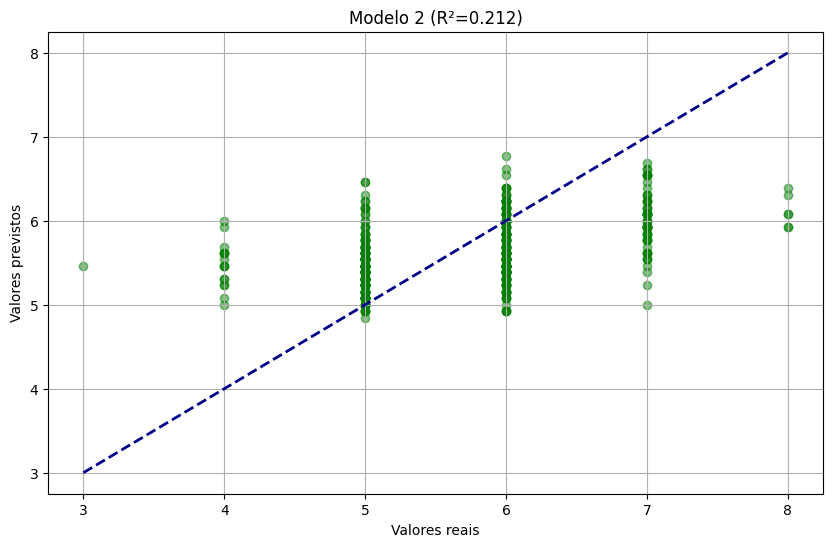

In [ ]:
# Visualizando os resultados da função previsão
plt.figure(figsize=(10, 6))
# Gráfico de previsão versus valor real
plt.scatter(y_test, y_pred_2, color= 'green', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2, color= 'darkblue')
plt.title(f'Modelo 2 (R²={r2m2:.3f})')
plt.xlabel('Valores reais')
plt.ylabel('Valores previstos')
plt.grid(True)

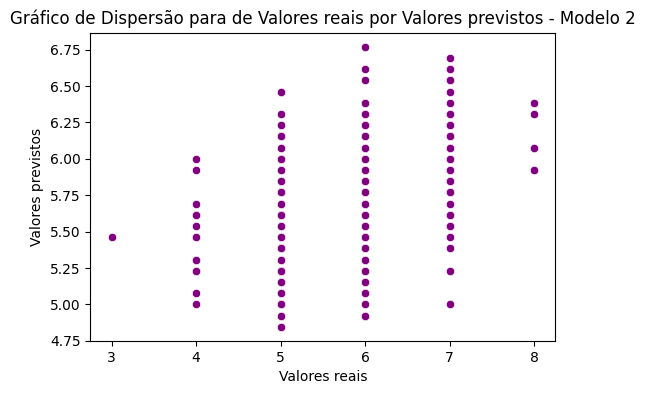

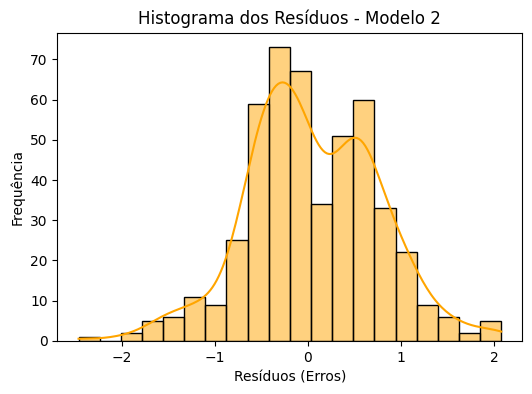

In [ ]:
# Calcula os resíduos (diferença entre valores previstos e valores reais)
residuals = y_test - y_pred_2

# Plotar um gráfico de dispersão dos valores previstos em relação aos valores reais
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=y_pred_2, color='purple')
plt.xlabel('Valores reais')
plt.ylabel('Valores previstos')
plt.title('Gráfico de Dispersão para de Valores reais por Valores previstos - Modelo 2')
plt.show()

# Plotar um histograma dos resíduos
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, color='orange')
plt.xlabel('Resíduos (Erros)')
plt.ylabel('Frequência')
plt.title('Histograma dos Resíduos - Modelo 2')
plt.show()